# 보강 + 보정 LSTM 전력 예측 모델 — 성능 리포트

모델 코드는 **`LSTM_AIModel_Enhanced.py`** 에 있고, 이 노트북은 그 모델의 성능을 **수치와 그래프로** 보여준다. 기준선으로 기존 **일반 LSTM**(`LSTM_AIModel`과 같은 입력·구조)을 같은 조건에서 함께 학습해 비교한다.

| 모델 | 내용 |
|---|---|
| 일반 LSTM | 기존 13개 입력, LSTM(64)→LSTM(32)→Dense(16)→Dense(1) |
| 보강 LSTM | 같은 구조 + 오차 원인 변수(시간대·평소/최근 패턴·생산·인원·고온·누적 고온·급변 전조·다음 시간 계획값) + **peak 가중 학습** |
| **보강+보정** | 보강 LSTM + **잔차 보정** (GBM 2개 앙상블: ① peak 보정형 ② 일반 LSTM 예측을 함께 쓰는 스태킹형, out-of-fold 잔차로 학습) |

> 보강 LSTM은 1단계 중간 결과다. peak 가중 학습 때문에 단독으로는 저부하 시간에 과대예측이 생길 수 있고, 2단계 보정이 이를 바로잡는다. **최종 모델은 보강+보정**이다.

**검증 방식**: ① 8:2 분할 ② 확장 윈도우 (`LSTM_AIModel` 시나리오 D와 동일: 초기 50% 학습, 나머지를 4개 fold로 순서대로 테스트)

**보고 지표**: MSE · RMSE · MAE · MAPE · **R²** · 허용(±10%) 비율 · 과소/과대 비율 · peak 지표

> 처음 실행 시 모델을 모두 학습한다 (검증 구간 5개 × LSTM 8개, CPU 기준 약 50분, GPU면 훨씬 빠름). 결과는 `enhanced_results.pkl`에 저장되고, 다음부터는 `RETRAIN = False`면 저장된 결과를 불러와 바로 그래프를 그린다.

In [1]:
import os, pickle, platform, warnings
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib import font_manager
warnings.filterwarnings("ignore")

from LSTM_AIModel_Enhanced import (load_data, add_driver_features, split_82, expanding_window, combine,
                                   metrics, peak_metrics, daily_peak_table, CFG, MODEL_NAMES)

DATA_PATH  = "okm_augumented_2021_processed.xlsx"
CACHE_PATH = "enhanced_results.pkl"
RETRAIN    = not os.path.exists(CACHE_PATH)      # True로 바꾸면 강제로 다시 학습

# 한글 폰트
_cands = {"Darwin": ["AppleGothic"], "Windows": ["Malgun Gothic"]}.get(platform.system(), []) + \
         ["NanumGothic", "Noto Sans CJK KR", "Noto Sans KR", "Noto Sans CJK JP", "UnDotum"]
_names = {f.name for f in font_manager.fontManager.ttflist}
_font = next((f for f in _cands if f in _names), None)
if _font: mpl.rcParams["font.family"] = _font
mpl.rcParams["axes.unicode_minus"] = False
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
COLORS = {"실제": "black", "일반 LSTM": "tab:gray", "보강 LSTM": "tab:blue", "보강+보정": "tab:red"}

df = load_data(DATA_PATH)
D  = add_driver_features(df)
print(f"데이터 {len(D):,}행 | {D.datetime.min():%Y-%m-%d} ~ {D.datetime.max():%Y-%m-%d}")
print(f"입력 변수: 일반 LSTM {len(D.attrs['base_feats'])}개 → 보강 LSTM {len(D.attrs['aug_feats'])}개")
print("주요 설정:", {k: CFG[k] for k in ["USE_KNOWN_FUTURE", "N_OOF", "PEAK_Q", "PEAK_W", "RESID_MODEL", "RESID_PEAK_W", "STACK_BASE", "EPOCHS"]})

/home/kampuser/.local/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/kampuser/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.4.0' currently installed).
  from pandas.core import (
2026-10-03 23:26:02.081695: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-10-03 23:26:02.103605: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-10-03 23:26:02.110585: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] U

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

데이터 6,168행 | 2021-01-01 ~ 2021-09-14
입력 변수: 일반 LSTM 13개 → 보강 LSTM 49개
주요 설정: {'USE_KNOWN_FUTURE': True, 'N_OOF': 3, 'PEAK_Q': 0.85, 'PEAK_W': 2.0, 'RESID_MODEL': 'gbm', 'RESID_PEAK_W': 2.0, 'STACK_BASE': True, 'EPOCHS': 50}


In [2]:
# ------------------------- 학습 (또는 저장된 결과 불러오기) -------------------------
KEEP = ["name", "rows", "datetime", "y", "preds", "alpha", "tr_end", "te_end", "full_pred"]
def slim(r): return {k: r[k] for k in KEEP}

if RETRAIN:
    RES_82  = slim(split_82(D))
    RES_EXP = [slim(r) for r in expanding_window(D)]
    pickle.dump({"RES_82": RES_82, "RES_EXP": RES_EXP, "CFG": CFG}, open(CACHE_PATH, "wb"))
    print("저장:", CACHE_PATH)
else:
    _c = pickle.load(open(CACHE_PATH, "rb")); RES_82, RES_EXP = _c["RES_82"], _c["RES_EXP"]
    print("저장된 결과 사용:", CACHE_PATH)
EXP = combine(RES_EXP)

I0000 00:00:1791037565.506440    1025 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1791037565.571463    1025 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1791037565.571793    1025 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1791037565.574651    1025 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

[8:2] 학습 4,934 / 테스트 1,234 | alpha=[1.0, 0.9] | 일반 LSTM MAE 9.16 R2 0.9522 | 보강 LSTM MAE 8.80 R2 0.9621 | 보강+보정 MAE 6.17 R2 0.9790 (362s)
[Fold 1] 학습 3,084 / 테스트 771 | alpha=[1.0, 1.0] | 일반 LSTM MAE 7.83 R2 0.9552 | 보강 LSTM MAE 15.59 R2 0.7499 | 보강+보정 MAE 7.41 R2 0.9552 (283s)
[Fold 2] 학습 3,855 / 테스트 771 | alpha=[1.0, 1.0] | 일반 LSTM MAE 8.49 R2 0.9579 | 보강 LSTM MAE 7.61 R2 0.9675 | 보강+보정 MAE 5.09 R2 0.9848 (308s)
[Fold 3] 학습 4,626 / 테스트 771 | alpha=[1.0, 1.0] | 일반 LSTM MAE 10.67 R2 0.9334 | 보강 LSTM MAE 15.28 R2 0.9092 | 보강+보정 MAE 7.31 R2 0.9687 (329s)
[Fold 4] 학습 5,397 / 테스트 771 | alpha=[1.0, 0.9] | 일반 LSTM MAE 8.08 R2 0.9602 | 보강 LSTM MAE 8.01 R2 0.9631 | 보강+보정 MAE 5.63 R2 0.9786 (372s)
저장: enhanced_results.pkl


## 1. 수치 성능

### 1-1. 8:2 분할

In [3]:
COLS = ["MSE", "RMSE", "MAE", "MAPE(%)", "R2", "평균오차(+과소)", "허용±10%(%)", "과소(%)", "과대(%)"]
def table(y, preds):
    t = pd.DataFrame({k: metrics(y, v) for k, v in preds.items()}).T[COLS]
    b = t.loc["일반 LSTM"]
    t["MAE 개선(%)"]  = (1 - t["MAE"] / b["MAE"]) * 100
    t["RMSE 개선(%)"] = (1 - t["RMSE"] / b["RMSE"]) * 100
    t["R2 변화"]      = t["R2"] - b["R2"]
    return t

TBL_82 = table(RES_82["y"], RES_82["preds"])
print(f"테스트 기간: {pd.Timestamp(RES_82['datetime'][0]):%Y-%m-%d} ~ {pd.Timestamp(RES_82['datetime'][-1]):%Y-%m-%d} ({len(RES_82['y']):,}시간)")
display(TBL_82.round(3))

테스트 기간: 2021-07-25 ~ 2021-09-14 (1,234시간)


,MSE,RMSE,MAE,MAPE(%),R2,평균오차(+과소),허용±10%(%),과소(%),과대(%),MAE 개선(%),RMSE 개선(%),R2 변화
일반 LSTM,180.558,13.437,9.158,10.763,0.952,2.877,72.528,16.775,10.697,0.000,0.000,0.000
보강 LSTM,143.306,11.971,8.802,15.987,0.962,2.911,73.663,17.504,8.833,3.889,10.911,0.010
보강+보정,79.209,8.900,6.166,11.233,0.979,0.075,87.682,4.538,7.780,32.675,33.766,0.027


### 1-2. 확장 윈도우 (fold별 + 전체)

In [4]:
rows = []
for r in RES_EXP:
    for k, v in r["preds"].items():
        rows.append({"Fold": r["name"],
                     "테스트 기간": f"{pd.Timestamp(r['datetime'][0]):%m/%d}~{pd.Timestamp(r['datetime'][-1]):%m/%d}",
                     "학습 수": r["tr_end"], "모델": k, **metrics(r["y"], v)})
FOLD_TBL = pd.DataFrame(rows)
display(FOLD_TBL.pivot_table(index=["Fold", "테스트 기간"], columns="모델", values=["MAE", "RMSE", "R2", "MAPE(%)"], sort=False)
        .reindex(columns=MODEL_NAMES, level=1).round(3))

TBL_EXP = table(EXP["y"], EXP["preds"])
FOLD_MEAN = FOLD_TBL.groupby("모델")[["MSE", "RMSE", "MAE", "MAPE(%)", "R2"]].mean().reindex(MODEL_NAMES)
print("\n[확장 윈도우 전체 (모든 fold 테스트 구간을 합쳐 계산)]"); display(TBL_EXP.round(3))
print("[확장 윈도우 fold 평균 (LSTM_AIModel 시나리오 D 요약과 같은 방식)]"); display(FOLD_MEAN.round(4))

MAE                   RMSE                      R2                MAPE(%)                
모델                 일반 LSTM 보강 LSTM  보강+보정 일반 LSTM 보강 LSTM   보강+보정 일반 LSTM 보강 LSTM  보강+보정 일반 LSTM 보강 LSTM   보강+보정
Fold   테스트 기간                                                                                                   
Fold 1 05/09~06/10   7.832  15.587  7.407  11.147  26.334  11.146   0.955   0.750  0.955  10.410  36.895  13.713
Fold 2 06/10~07/12   8.490   7.612  5.091  11.835  10.400   7.108   0.958   0.967  0.985   9.433   8.503   7.011
Fold 3 07/12~08/13  10.665  15.278  7.310  16.476  19.244  11.291   0.933   0.909  0.969  11.152  27.283  10.677
Fold 4 08/13~09/14   8.075   8.014  5.626  11.527  11.091   8.456   0.960   0.963  0.979   9.073  12.010   7.316


[확장 윈도우 전체 (모든 fold 테스트 구간을 합쳐 계산)]


,MSE,RMSE,MAE,MAPE(%),R2,평균오차(+과소),허용±10%(%),과소(%),과대(%),MAE 개선(%),RMSE 개선(%),R2 변화
일반 LSTM,167.166,12.929,8.765,10.022,0.951,3.453,76.200,17.218,6.582,0.000,0.000,0.000
보강 LSTM,323.739,17.993,11.623,21.224,0.905,-0.511,66.051,14.981,18.969,-32.598,-39.163,-0.046
보강+보정,93.434,9.666,6.359,9.693,0.972,-0.541,86.284,5.577,8.139,27.459,25.238,0.022


[확장 윈도우 fold 평균 (LSTM_AIModel 시나리오 D 요약과 같은 방식)]


,MSE,RMSE,MAE,MAPE(%),R2
모델,,,,,
일반 LSTM,167.1659,12.7463,8.7654,10.0171,0.9517
보강 LSTM,323.7395,16.7671,11.6228,21.1729,0.8974
보강+보정,93.4343,9.5001,6.3585,9.6794,0.9718


### 1-3. 요약: 일반 LSTM 대비

RMSE     MAE  MAPE(%)     R2  허용±10%(%)  MAE 개선(%)  RMSE 개선(%)  R2 변화
8:2 분할 일반 LSTM  13.437   9.158   10.763  0.952     72.528      0.000       0.000  0.000
       보강 LSTM  11.971   8.802   15.987  0.962     73.663      3.889      10.911  0.010
       보강+보정     8.900   6.166   11.233  0.979     87.682     32.675      33.766  0.027
확장 윈도우 일반 LSTM  12.929   8.765   10.022  0.951     76.200      0.000       0.000  0.000
       보강 LSTM  17.993  11.623   21.224  0.905     66.051    -32.598     -39.163 -0.046
       보강+보정     9.666   6.359    9.693  0.972     86.284     27.459      25.238  0.022

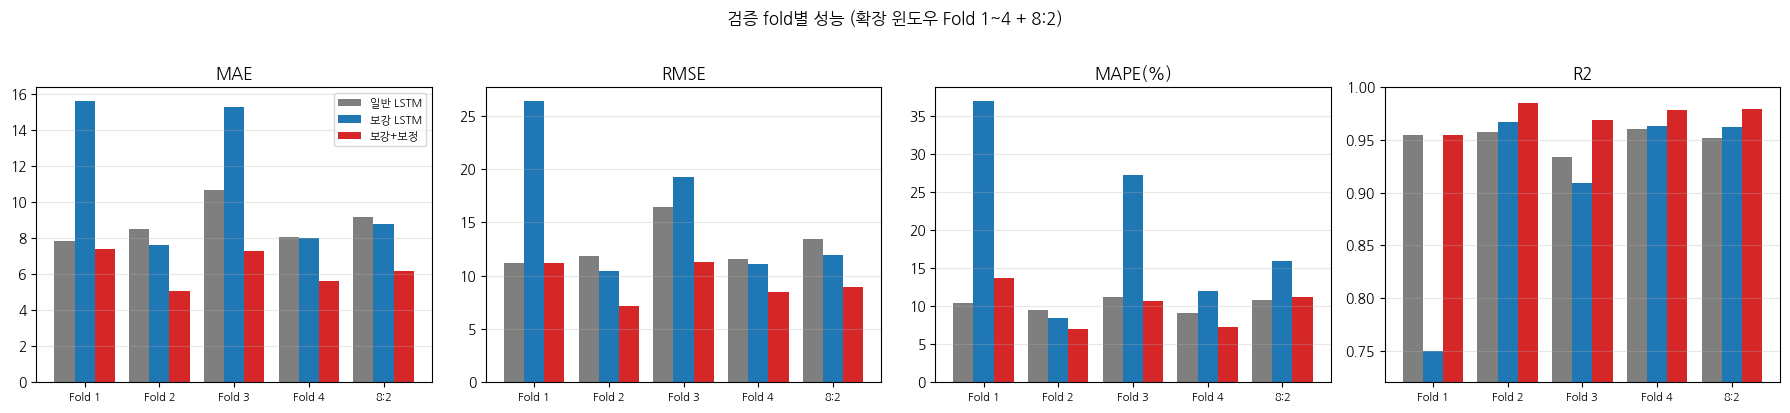

In [5]:
SUMMARY = pd.concat({"8:2 분할": TBL_82, "확장 윈도우": TBL_EXP})[["RMSE", "MAE", "MAPE(%)", "R2", "허용±10%(%)", "MAE 개선(%)", "RMSE 개선(%)", "R2 변화"]]
display(SUMMARY.round(3))

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
labels = [r["name"] for r in RES_EXP] + ["8:2"]
x = np.arange(len(labels))
for j, m in enumerate(["MAE", "RMSE", "MAPE(%)", "R2"]):
    for i, k in enumerate(MODEL_NAMES):
        vals = list(FOLD_TBL[FOLD_TBL["모델"] == k][m].values) + [TBL_82.loc[k, m]]
        ax[j].bar(x + (i - 1) * 0.27, vals, 0.27, color=COLORS[k], label=k)
    ax[j].set_xticks(x); ax[j].set_xticklabels(labels, fontsize=8); ax[j].set_title(m); ax[j].grid(alpha=.3, axis="y")
    if m == "R2": ax[j].set_ylim(max(0, min(FOLD_TBL["R2"].min(), TBL_82["R2"].min()) - 0.03), 1)
ax[0].legend(fontsize=8)
plt.suptitle("검증 fold별 성능 (확장 윈도우 Fold 1~4 + 8:2)", y=1.02); plt.tight_layout(); plt.show()

## 2. 시각화

### 2-1. 실제 vs 예측 시계열 (8:2 테스트 구간)

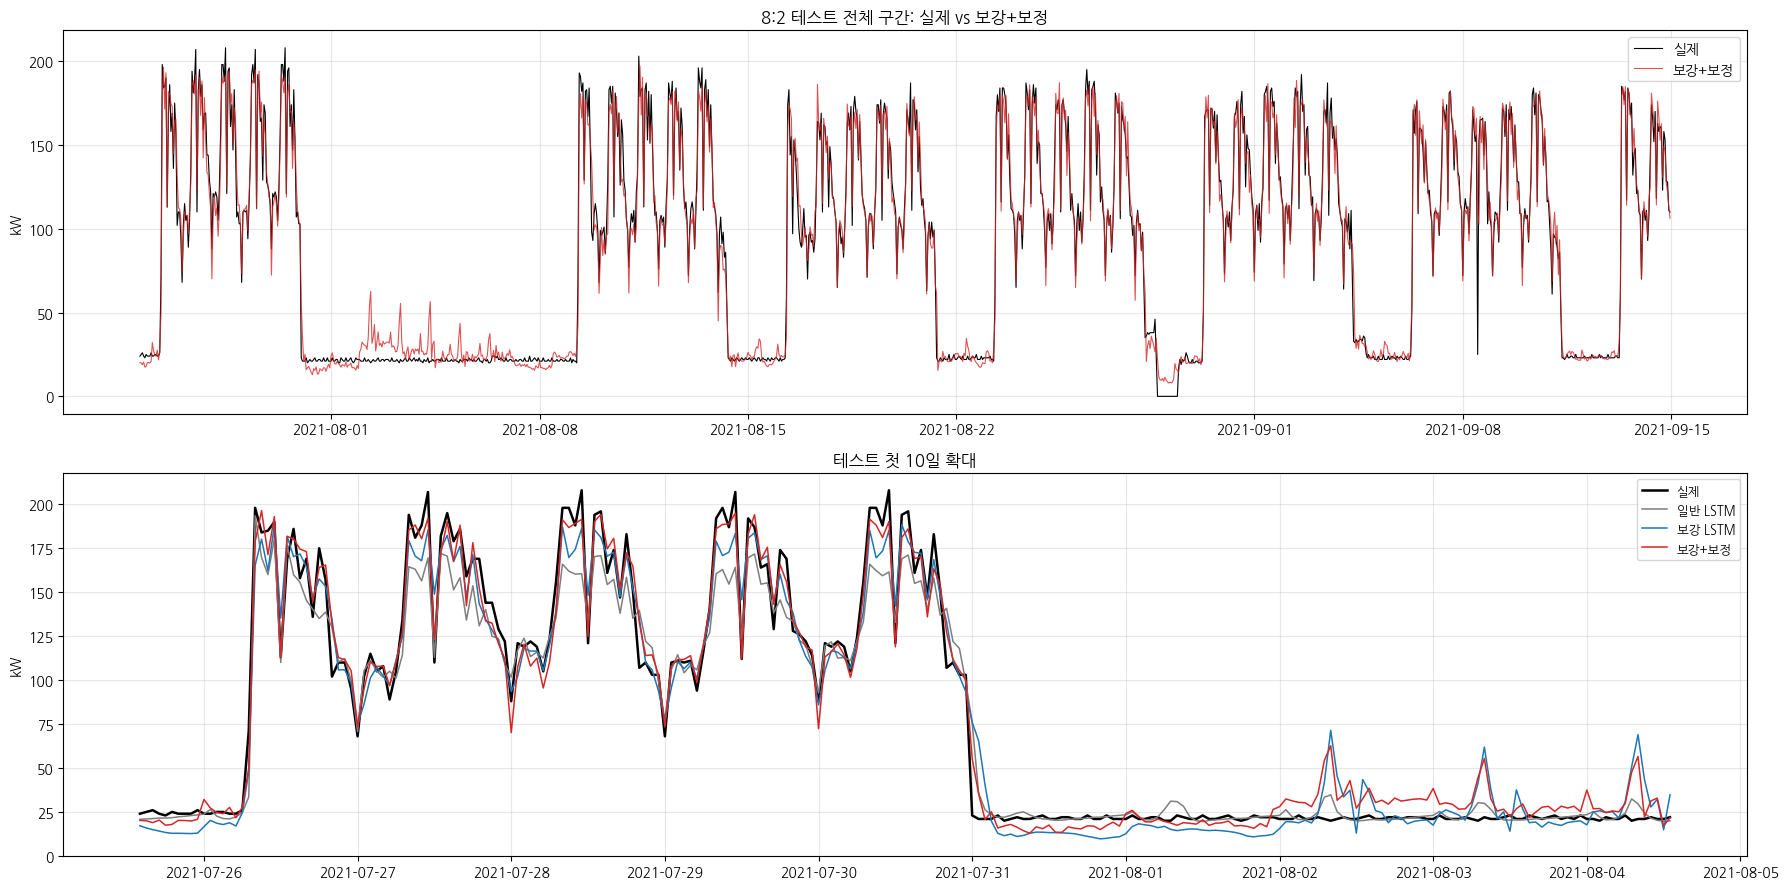

In [6]:
t82 = pd.to_datetime(RES_82["datetime"])
fig, ax = plt.subplots(2, 1, figsize=(18, 9))
ax[0].plot(t82, RES_82["y"], color="k", lw=.8, label="실제")
ax[0].plot(t82, RES_82["preds"]["보강+보정"], color=COLORS["보강+보정"], lw=.8, alpha=.8, label="보강+보정")
ax[0].set(title="8:2 테스트 전체 구간: 실제 vs 보강+보정", ylabel="kW"); ax[0].legend(); ax[0].grid(alpha=.3)
n = 24 * 10
for k in ["실제"] + MODEL_NAMES:
    v = RES_82["y"] if k == "실제" else RES_82["preds"][k]
    ax[1].plot(t82[:n], v[:n], color=COLORS[k], lw=1.8 if k == "실제" else 1.1, label=k)
ax[1].set(title="테스트 첫 10일 확대", ylabel="kW"); ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

### 2-2. 산점도 (실제 vs 예측, R²) · 오차 분포

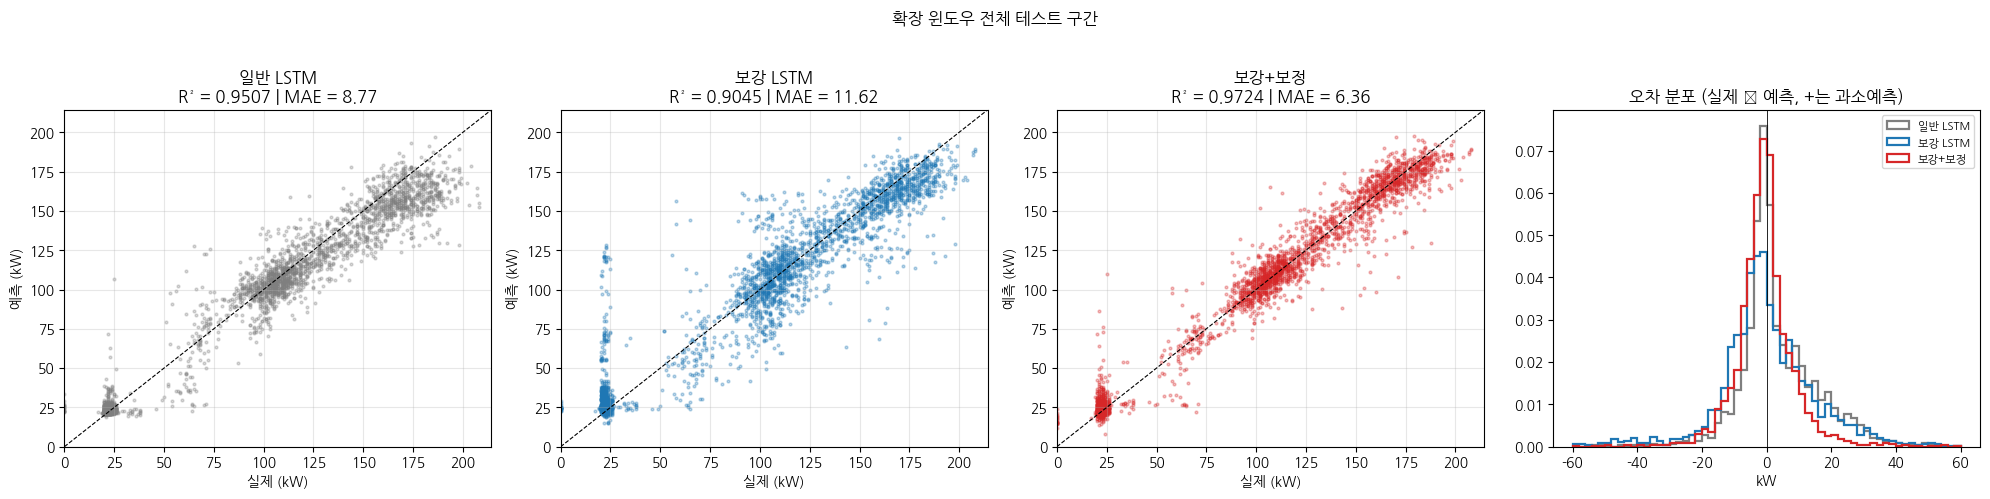

In [7]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4.8))
lim = [0, max(EXP["y"].max(), max(v.max() for v in EXP["preds"].values())) * 1.03]
for j, k in enumerate(MODEL_NAMES):
    m = metrics(EXP["y"], EXP["preds"][k])
    ax[j].scatter(EXP["y"], EXP["preds"][k], s=4, alpha=.3, color=COLORS[k])
    ax[j].plot(lim, lim, "k--", lw=.8); ax[j].set_xlim(lim); ax[j].set_ylim(lim)
    ax[j].set(title=f"{k}\nR² = {m['R2']:.4f} | MAE = {m['MAE']:.2f}", xlabel="실제 (kW)", ylabel="예측 (kW)"); ax[j].grid(alpha=.3)
bins = np.linspace(-60, 60, 61)
for k in MODEL_NAMES:
    ax[3].hist(EXP["y"] - EXP["preds"][k], bins=bins, histtype="step", lw=1.6, color=COLORS[k], label=k, density=True)
ax[3].axvline(0, color="k", lw=.6); ax[3].set(title="오차 분포 (실제 − 예측, +는 과소예측)", xlabel="kW"); ax[3].legend(fontsize=8)
plt.suptitle("확장 윈도우 전체 테스트 구간", y=1.03); plt.tight_layout(); plt.show()

### 2-3. 시간대별 · 요일 유형별 성능

,일반 LSTM,보강 LSTM,보강+보정,R2(보강+보정),R2(일반 LSTM)
주말,4.681,9.483,4.483,0.938,0.918
평일,10.513,12.538,7.161,0.952,0.908


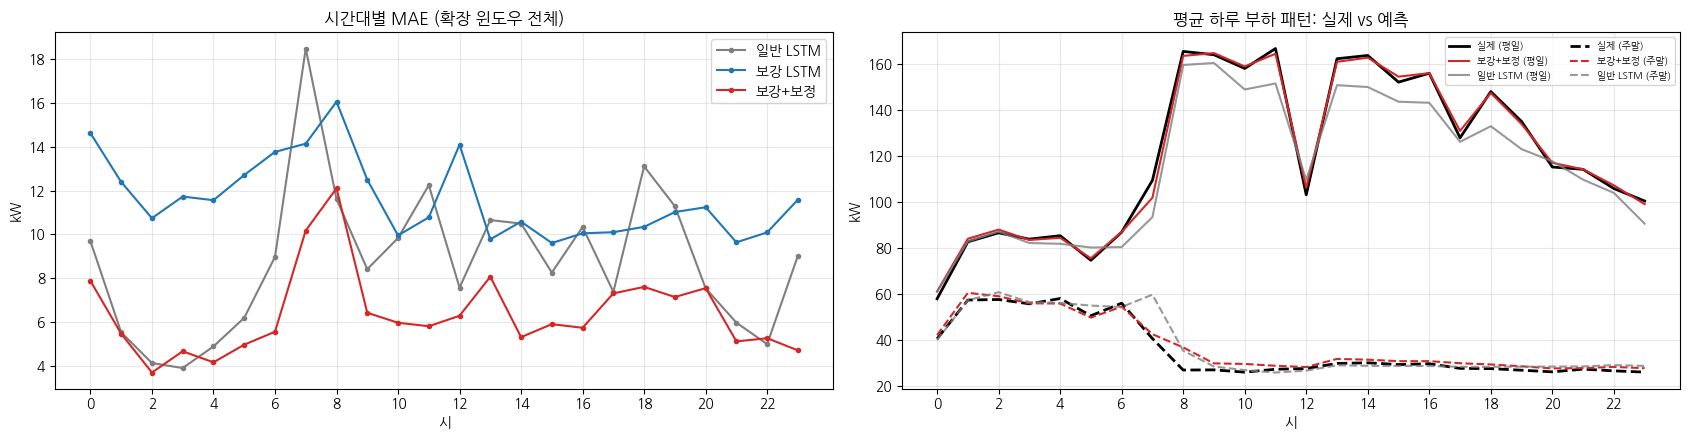

In [8]:
E = D.loc[EXP["rows"], ["datetime", "hour", "workday", "생산량", "공장인원", "기온", "CDH24"]].copy()
E["y"] = EXP["y"]
for k in MODEL_NAMES: E[k] = EXP["preds"][k]

HOUR_TBL = pd.DataFrame({k: E.assign(ae=(E["y"] - E[k]).abs()).groupby("hour")["ae"].mean() for k in MODEL_NAMES})
DAY_TBL = pd.DataFrame({dt: {k: metrics(sub["y"], sub[k])["MAE"] for k in MODEL_NAMES} | {"R2(보강+보정)": metrics(sub["y"], sub["보강+보정"])["R2"],
                                                                                    "R2(일반 LSTM)": metrics(sub["y"], sub["일반 LSTM"])["R2"]}
                        for dt, sub in E.groupby(np.where(E["workday"] == 1, "평일", "주말"))}).T
display(DAY_TBL.round(3))

fig, ax = plt.subplots(1, 2, figsize=(17, 4.5))
for k in MODEL_NAMES: ax[0].plot(HOUR_TBL.index, HOUR_TBL[k], marker="o", ms=3, color=COLORS[k], label=k)
ax[0].set(title="시간대별 MAE (확장 윈도우 전체)", xlabel="시", ylabel="kW"); ax[0].set_xticks(range(0, 24, 2)); ax[0].legend(); ax[0].grid(alpha=.3)
prof = E.groupby(["workday", "hour"])[["y"] + MODEL_NAMES].mean()
for wd, ls in [(1, "-"), (0, "--")]:
    p = prof.loc[wd]
    ax[1].plot(p.index, p["y"], ls, color="k", lw=2, label=f"실제 ({'평일' if wd else '주말'})")
    ax[1].plot(p.index, p["보강+보정"], ls, color=COLORS["보강+보정"], label=f"보강+보정 ({'평일' if wd else '주말'})")
    ax[1].plot(p.index, p["일반 LSTM"], ls, color=COLORS["일반 LSTM"], alpha=.8, label=f"일반 LSTM ({'평일' if wd else '주말'})")
ax[1].set(title="평균 하루 부하 패턴: 실제 vs 예측", xlabel="시", ylabel="kW"); ax[1].set_xticks(range(0, 24, 2)); ax[1].legend(fontsize=7, ncol=2); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 3. 7월 peak 분석

7월은 기온이 30℃를 넘는 날이 이어지면서 **일 최대전력이 학습 기간 최고치(≈202kW)를 넘는 날**(204~208kW)이 처음 나온다. 일반 LSTM은 학습 범위 밖의 peak를 낮게 예측하는 경향이 있어, 보강 모델에 다음을 넣었다.

- **peak 가중 학습**: 학습 구간 target 상위 15% 시점의 손실 가중치를 3배로 → peak를 덜 깎아 먹음
- **최근 평소 패턴**(`recent_usual`, `recent_peak_h`): 같은 시각·근무유형의 *최근 5일* 평균/최대 → 계절 변화에 빠르게 적응 (전체 평균은 겨울 값이 섞여 여름 peak를 낮게 봄)
- **당일 최고기온**(`tmax_day`), **근무일 주간 냉방 부하**(`heat_work_day`), 72시간 누적 고온(`CDH72`)
- **잔차 보정도 고부하 시점 가중**(LSTM 예측 상위 15% 가중치 3배) + 어제/지난주 같은 시각 전력, 최근 24시간 최대, 어제 같은 시각의 오차
- **보정 앙상블**: 보정 모델 ①(peak 보정형)은 peak 오차가 가장 작고, ②(일반 LSTM 예측까지 쓰는 스태킹형)는 전체 MAE·MAPE가 가장 작아 둘을 평균

※ 7/13, 7/15는 근무일인데 **생산량·공장인원이 0으로 기록**돼 있다(전력은 정상 가동 수준 → 기록 누락으로 보임). 이런 날은 생산 관련 입력이 틀린 정보를 주므로 오차가 남을 수 있다.

7월은 확장 윈도우 Fold 2(~7/12)와 Fold 3(7/12~)의 테스트 구간에 모두 들어 있다.

In [9]:
jul = pd.to_datetime(EXP["datetime"]).month == 7
J = {k: v[jul] for k, v in EXP["preds"].items()}; Jy = EXP["y"][jul]; Jt = EXP["datetime"][jul]
JUL_TBL = pd.concat([pd.DataFrame({k: metrics(Jy, v) for k, v in J.items()}).T[["RMSE", "MAE", "MAPE(%)", "R2"]],
                     peak_metrics(Jt, Jy, J)], axis=1)
print("[7월 전체 + peak 지표]  일 peak = 근무일(실제 peak ≥ 100kW)의 하루 최대전력, 상위10% = 7월 실제 부하 상위 10% 시간")
display(JUL_TBL.round(3))

JUL_DAY = daily_peak_table(Jt, Jy, J)
JUL_DAY = JUL_DAY[JUL_DAY["실제 peak"] >= 100]
print("\n[7월 근무일 일 최대전력 비교 (오차 + = 과소예측)]")
display(JUL_DAY[["실제 peak"] + [f"{k} peak" for k in MODEL_NAMES] + [f"{k} peak오차" for k in MODEL_NAMES]].round(1))

[7월 전체 + peak 지표]  일 peak = 근무일(실제 peak ≥ 100kW)의 하루 최대전력, 상위10% = 7월 실제 부하 상위 10% 시간


,RMSE,MAE,MAPE(%),R2,일 peak MAE,일 peak 평균오차(+과소),상위10% 시간 MAE,상위10% 평균오차(+과소)
일반 LSTM,16.741,11.413,10.788,0.921,19.017,16.599,30.639,30.345
보강 LSTM,18.339,13.422,15.799,0.905,13.672,13.362,18.459,18.282
보강+보정,10.911,7.123,8.589,0.966,8.706,6.470,11.007,10.528



[7월 근무일 일 최대전력 비교 (오차 + = 과소예측)]


,실제 peak,일반 LSTM peak,보강 LSTM peak,보강+보정 peak,일반 LSTM peak오차,보강 LSTM peak오차,보강+보정 peak오차
date,,,,,,,
2021-07-01,190.0,166.300003,169.399994,183.1,23.7,20.6,6.9
2021-07-02,179.0,162.899994,170.000000,174.2,16.1,9.0,4.8
2021-07-03,106.0,105.300003,103.300003,110.9,0.7,2.7,-4.9
2021-07-05,173.0,186.600006,175.399994,186.7,-13.6,-2.4,-13.7
2021-07-06,180.0,164.300003,171.300003,176.4,15.7,8.7,3.6
2021-07-07,181.0,169.399994,172.000000,178.0,11.6,9.0,3.0
2021-07-08,190.0,160.500000,174.699997,182.9,29.5,15.3,7.1
2021-07-09,181.0,164.199997,168.300003,177.0,16.8,12.7,4.0
2021-07-10,101.0,103.099998,102.099998,108.9,-2.1,-1.1,-7.9


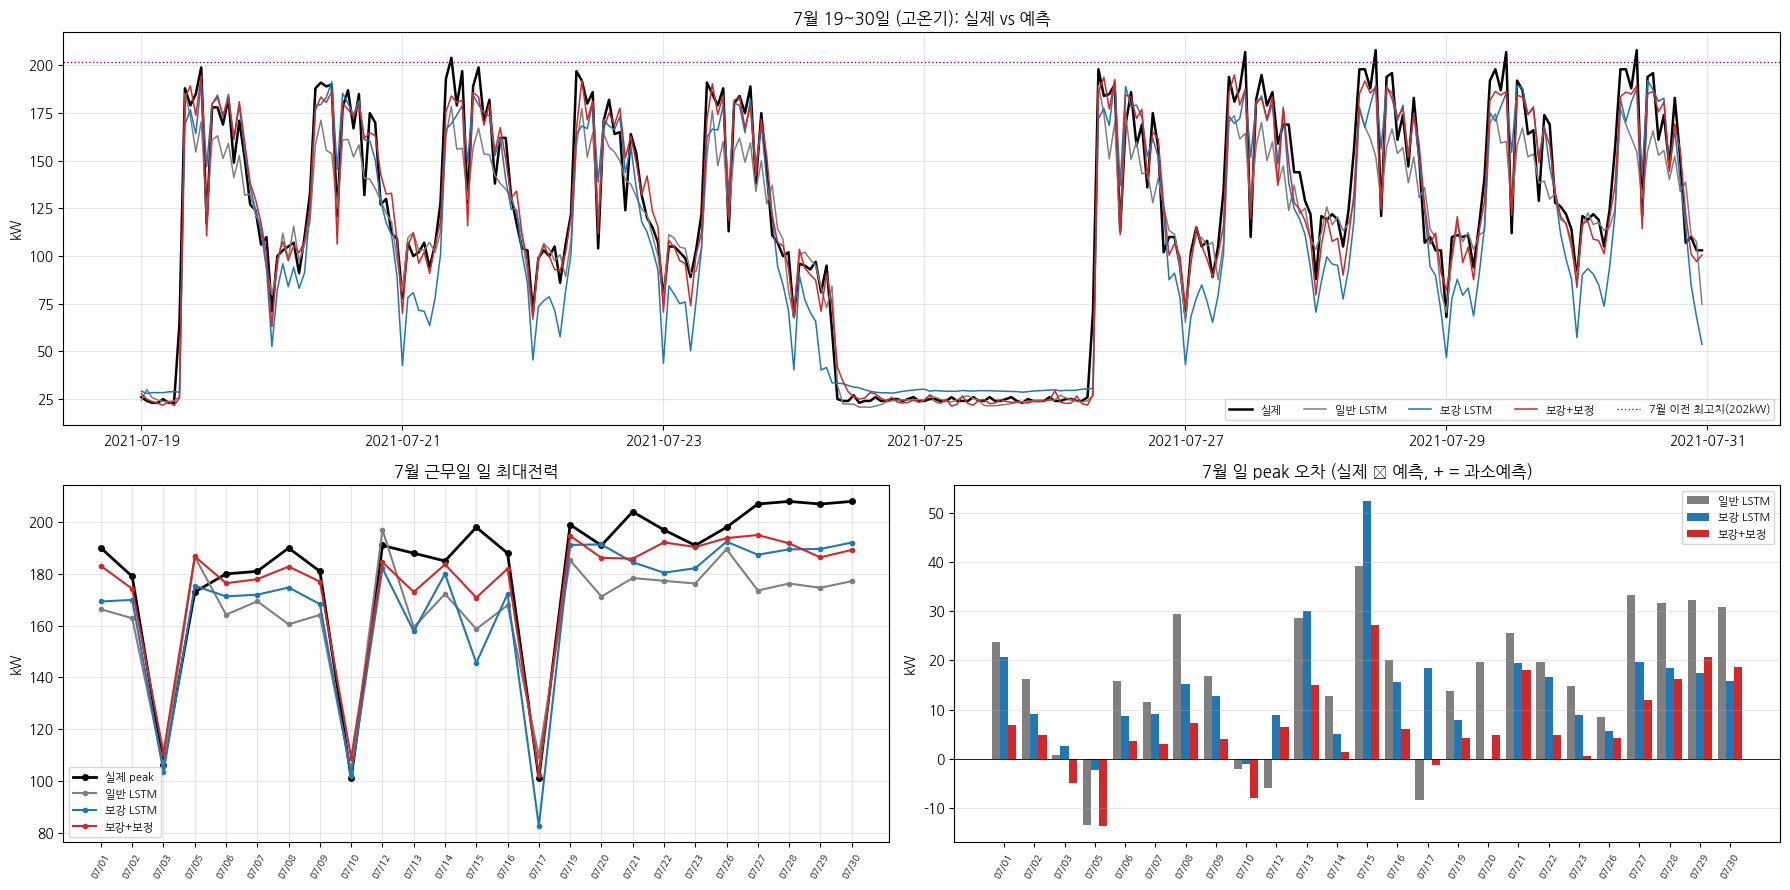

In [10]:
fig = plt.figure(figsize=(18, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[1.1, 1])
a = fig.add_subplot(gs[0, :])
ax = np.array([[None, None], [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]], dtype=object)
# (1) 7월 시계열 (하순 고온기 확대)
jt = pd.to_datetime(Jt); sel = (jt >= "2021-07-19") & (jt < "2021-07-31")
a.plot(jt[sel], Jy[sel], color="k", lw=1.8, label="실제")
for k in MODEL_NAMES: a.plot(jt[sel], J[k][sel], color=COLORS[k], lw=1.1, label=k)
a.axhline(202, color="purple", ls=":", lw=1, label="7월 이전 최고치(202kW)")
a.set(title="7월 19~30일 (고온기): 실제 vs 예측", ylabel="kW"); a.legend(fontsize=8, ncol=5); a.grid(alpha=.3)

# (2) 일 최대전력: 실제 vs 예측
x = np.arange(len(JUL_DAY))
ax[1, 0].plot(x, JUL_DAY["실제 peak"], "k-o", ms=4, lw=2, label="실제 peak")
for k in MODEL_NAMES: ax[1, 0].plot(x, JUL_DAY[f"{k} peak"], "-o", ms=3, color=COLORS[k], label=k)
ax[1, 0].set_xticks(x); ax[1, 0].set_xticklabels([f"{d:%m/%d}" for d in JUL_DAY.index], rotation=60, fontsize=7)
ax[1, 0].set(title="7월 근무일 일 최대전력", ylabel="kW"); ax[1, 0].legend(fontsize=8); ax[1, 0].grid(alpha=.3)

# (3) 일 peak 오차 막대
w = 0.27
for i, k in enumerate(MODEL_NAMES):
    ax[1, 1].bar(x + (i - 1) * w, JUL_DAY[f"{k} peak오차"], w, color=COLORS[k], label=k)
ax[1, 1].axhline(0, color="k", lw=.6); ax[1, 1].set_xticks(x); ax[1, 1].set_xticklabels([f"{d:%m/%d}" for d in JUL_DAY.index], rotation=60, fontsize=7)
ax[1, 1].set(title="7월 일 peak 오차 (실제 − 예측, + = 과소예측)", ylabel="kW"); ax[1, 1].legend(fontsize=8); ax[1, 1].grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

### 3-1. 월별 peak 지표 (확장 윈도우 전체 기간)

In [11]:
mon = pd.to_datetime(EXP["datetime"]).month
rows = []
for mth in sorted(np.unique(mon)):
    s = mon == mth
    pm = peak_metrics(EXP["datetime"][s], EXP["y"][s], {k: v[s] for k, v in EXP["preds"].items()})
    for k in MODEL_NAMES:
        rows.append({"월": f"{mth}월", "모델": k, "MAE": metrics(EXP["y"][s], EXP["preds"][k][s])["MAE"],
                     "R2": metrics(EXP["y"][s], EXP["preds"][k][s])["R2"], **pm.loc[k].to_dict()})
MONTH_TBL = pd.DataFrame(rows)
display(MONTH_TBL.pivot_table(index="월", columns="모델", values=["MAE", "R2", "일 peak MAE", "상위10% 시간 MAE"], sort=False)
        .reindex(columns=MODEL_NAMES, level=1).round(3))

MAE                     R2                일 peak MAE                상위10% 시간 MAE                
모델 일반 LSTM 보강 LSTM  보강+보정 일반 LSTM 보강 LSTM  보강+보정    일반 LSTM 보강 LSTM  보강+보정      일반 LSTM 보강 LSTM   보강+보정
월                                                                                                      
5월   7.691  11.569  7.482   0.957   0.855  0.955      6.895   6.370  6.691        8.667  11.836   6.588
6월   8.347  13.101  5.725   0.955   0.832  0.976      9.029  11.812  6.171       16.916  15.811   7.218
7월  11.413  13.422  7.123   0.921   0.905  0.966     19.017  13.672  8.706       30.639  18.459  11.007
8월   7.562  10.454  5.848   0.966   0.954  0.981      7.820   8.950  5.237       18.246  11.929   8.015
9월   8.192   7.145  5.349   0.955   0.966  0.976      6.510   6.135  5.291       14.602   9.345   6.783

## 4. 오차 원인 구간별 · 급증 탐지 성능
오차 분석(`Error_Driver_Pipeline`)에서 문제였던 조건별로 일반 LSTM과 비교한다 (확장 윈도우 전체 테스트 구간).

표본  MAE_일반 LSTM  과소%_일반 LSTM  과대%_일반 LSTM  MAE_보강+보정  과소%_보강+보정  과대%_보강+보정  MAE 개선(%)
조건    구간                                                                                             
부하 수준 Q1 낮음    771          3.1          0.0          3.6        4.3        0.1       10.4      -39.7
      Q2       771          8.2         15.7         15.4        6.2        8.4       11.3       24.5
      Q3       771          8.4         16.0          6.2        6.9        6.6        8.9       18.4
      Q4 높음    771         15.4         37.2          1.0        8.1        7.1        1.9       47.3
생산량   0       1196          5.0          6.9          5.4        5.3        5.2        9.1       -6.1
      생산 낮음    630          8.0         14.9         10.6        6.3        7.6        8.4       20.5
      생산 중간    629         10.8         19.9          8.4        7.1        3.8       10.3       34.6
      생산 높음    629         14.7         36.6          2.9        7.7        6.0        3.8       47.6
공장인원  0       1196          5.0          6.9          5.4        5.3        5.2        9.1       -6.1
      인원 낮음    630          8.1         14.9          9.7        6.4        7.6        8.1       21.3
      인원 중간    629         11.0         21.6          7.6        7.1        4.1        9.1       35.7
      인원 높음    629         14.4         34.8          4.6        7.7        5.7        5.4       46.7
기온    <25℃    2127          7.9         15.0          7.3        6.0        5.7        8.3       24.1
      25~28℃   599         10.1         18.5          6.2        7.4        6.0        8.7       27.4
      ≥28℃     358         11.3         27.9          3.1        6.6        4.2        6.4       41.6
누적고온  0        941          8.2         16.0          7.2        6.1        4.9        8.1       25.6
      CDH 낮음   715          8.8         17.3          7.8        5.9        4.2        8.5       33.1
      CDH 중간   714          8.3         13.9          5.0        6.6        5.5        7.4       20.6
      CDH 높음   714         10.0         22.0          6.0        7.0        8.0        8.5       30.2
전력변화  급증       379         14.9         43.0          3.2       10.2       17.9        5.0       31.4
      급감       276         12.3         10.1         33.3        9.9        7.2       25.7       19.2
      그 외     2429          7.4         14.0          4.1        5.4        3.5        6.6       27.8


[급증(직전 대비 40%↑) 탐지 성능 — 8:2 테스트]


,TP,FN(미탐지),FP(오탐지),Precision,Recall,F1
일반 LSTM,28.0,47.0,11.0,0.7179,0.3733,0.4912
보강 LSTM,20.0,55.0,37.0,0.3509,0.2667,0.3030
보강+보정,58.0,17.0,34.0,0.6304,0.7733,0.6946


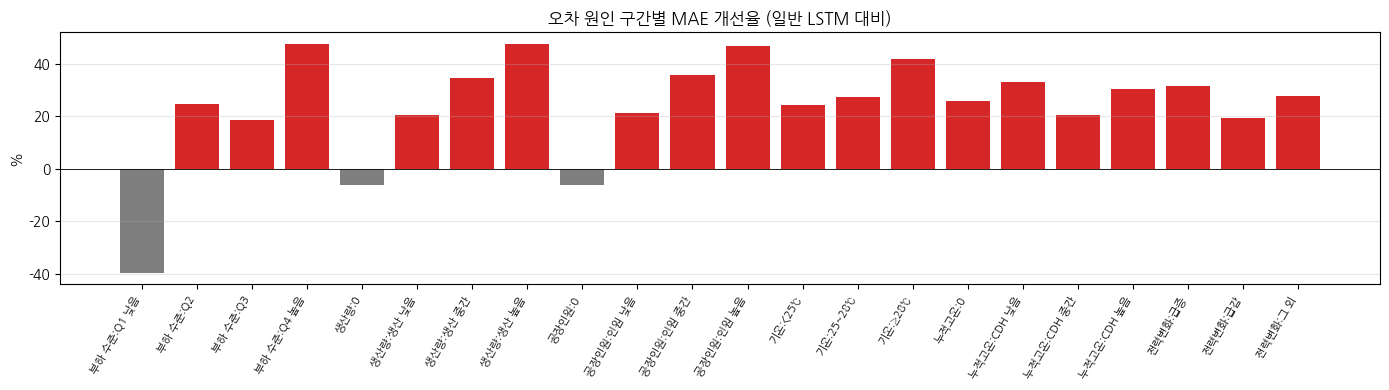

In [12]:
def tertile0(s, lab):
    labs = [f"{lab} 낮음", f"{lab} 중간", f"{lab} 높음"]
    out = pd.Series("0", index=s.index, dtype=object); pos = s[s > 0]
    if len(pos) > 3: out.loc[pos.index] = pd.qcut(pos.rank(method="first"), 3, labels=labs).astype(str)
    return pd.Categorical(out, categories=["0"] + labs, ordered=True)
prev = D["평균"].shift(1).loc[E.index].values
E["pchg"] = np.where(prev > 0, (E["y"] - prev) / np.where(prev > 0, prev, 1) * 100, np.nan)
SEGS = {"부하 수준": pd.qcut(E["y"].rank(method="first"), 4, labels=["Q1 낮음", "Q2", "Q3", "Q4 높음"]),
        "생산량": tertile0(E["생산량"], "생산"), "공장인원": tertile0(E["공장인원"], "인원"),
        "기온": pd.cut(E["기온"], [-99, 25, 28, 99], right=False, labels=["<25℃", "25~28℃", "≥28℃"]),
        "누적고온": tertile0(E["CDH24"], "CDH"),
        "전력변화": pd.Categorical(np.select([E["pchg"] >= 20, E["pchg"] <= -20], ["급증", "급감"], "그 외"), categories=["급증", "급감", "그 외"])}
seg_rows = []
for nm, g in SEGS.items():
    for lv, sub in E.groupby(g, observed=True):
        if len(sub) < 10: continue
        r = {"조건": nm, "구간": lv, "표본": len(sub)}
        for k in ["일반 LSTM", "보강+보정"]:
            m = metrics(sub["y"], sub[k]); r[f"MAE_{k}"] = m["MAE"]; r[f"과소%_{k}"] = m["과소(%)"]; r[f"과대%_{k}"] = m["과대(%)"]
        r["MAE 개선(%)"] = (1 - r["MAE_보강+보정"] / r["MAE_일반 LSTM"]) * 100
        seg_rows.append(r)
SEG_TBL = pd.DataFrame(seg_rows).set_index(["조건", "구간"])
display(SEG_TBL.round(1))

# 급증 탐지 (LSTM_AIModel과 같은 방식: 직전 대비 40% 이상 증가)
def surge_scores(y, p, th=0.40):
    ya, pa = pd.Series(y), pd.Series(p)
    real = (ya.pct_change() >= th).values[1:]; pred = (pa.pct_change() >= th).values[1:]
    tp, fn, fp = (real & pred).sum(), (real & ~pred).sum(), (~real & pred).sum()
    pr = tp / (tp + fp) if tp + fp else 0; rc = tp / (tp + fn) if tp + fn else 0
    return {"TP": tp, "FN(미탐지)": fn, "FP(오탐지)": fp, "Precision": pr, "Recall": rc, "F1": 2 * pr * rc / (pr + rc) if pr + rc else 0}
SURGE_TBL = pd.DataFrame({k: surge_scores(RES_82["y"], v) for k, v in RES_82["preds"].items()}).T
print("\n[급증(직전 대비 40%↑) 탐지 성능 — 8:2 테스트]"); display(SURGE_TBL.round(4))

fig, ax = plt.subplots(figsize=(14, 4))
labs = [f"{a}:{b}" for a, b in SEG_TBL.index]; v = SEG_TBL["MAE 개선(%)"].values
ax.bar(range(len(v)), v, color=["tab:red" if t > 0 else "tab:gray" for t in v]); ax.axhline(0, color="k", lw=.6)
ax.set_xticks(range(len(v))); ax.set_xticklabels(labs, rotation=60, ha="right", fontsize=8)
ax.set(title="오차 원인 구간별 MAE 개선율 (일반 LSTM 대비)", ylabel="%"); ax.grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

## 5. 저장

In [13]:
with pd.ExcelWriter("보강보정모델_성능리포트.xlsx") as w:
    SUMMARY.round(4).to_excel(w, sheet_name="요약")
    TBL_82.round(4).to_excel(w, sheet_name="8대2")
    FOLD_TBL.round(4).to_excel(w, sheet_name="확장윈도우_fold별", index=False)
    TBL_EXP.round(4).to_excel(w, sheet_name="확장윈도우_전체")
    JUL_TBL.round(4).to_excel(w, sheet_name="7월_peak지표")
    JUL_DAY.round(2).to_excel(w, sheet_name="7월_일peak")
    MONTH_TBL.round(4).to_excel(w, sheet_name="월별_peak", index=False)
    SEG_TBL.round(2).to_excel(w, sheet_name="오차원인구간")
    SURGE_TBL.round(4).to_excel(w, sheet_name="급증탐지")
    pd.DataFrame({"datetime": RES_82["datetime"], "실제": RES_82["y"], **RES_82["preds"]}).to_excel(w, sheet_name="8대2_예측값", index=False)
    pd.DataFrame({"datetime": EXP["datetime"], "실제": EXP["y"], **EXP["preds"]}).to_excel(w, sheet_name="확장윈도우_예측값", index=False)
print("저장 완료: 보강보정모델_성능리포트.xlsx")

저장 완료: 보강보정모델_성능리포트.xlsx
